In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer
import category_encoders as ce


from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

## Ejercicio práctico Regresión

https://www.kaggle.com/datasets/denkuznetz/taxi-price-prediction

Objetivo: Usar este dataset para construir un modelo de regresión que pueda predecir la tarifa a cobrar en un viaje de taxi teniendo en cuenta condiciones como clima, dia de la semana, distancia, etc.

## 1. Importar los datos

In [3]:
dataset_taxis = pd.read_csv('taxi_trip_pricing.csv')
dataset_taxis

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180
...,...,...,...,...,...,...,...,...,...,...,...
995,5.49,Afternoon,Weekend,4.0,Medium,Clear,2.39,0.62,0.49,58.39,34.4049
996,45.95,Night,Weekday,4.0,Medium,Clear,3.12,0.61,NaN,61.96,62.1295
997,7.70,Morning,Weekday,3.0,Low,Rain,2.08,1.78,NaN,54.18,33.1236
998,47.56,Morning,Weekday,1.0,Low,Clear,2.67,0.82,0.17,114.94,61.2090


In [ ]:
display(dataset_taxis['Time_of_Day'].value_counts())

display(dataset_taxis['Day_of_Week'].value_counts())

display(dataset_taxis['Traffic_Conditions'].value_counts())

display(dataset_taxis['Weather'].value_counts())



Time_of_Day
Afternoon    351
Morning      265
Evening      197
Night         89
Name: count, dtype: int64

Day_of_Week
Weekday    622
Weekend    283
Name: count, dtype: int64

Traffic_Conditions
Low       374
Medium    355
High      172
Name: count, dtype: int64

Weather
Clear    634
Rain     216
Snow      55
Name: count, dtype: int64

## 2. EDA (Exploratory Data Analysis)

In [5]:
dataset_taxis.shape

(1000, 11)

In [ ]:
## Revisar nulos y cantidad de registros por columna
dataset_taxis.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    str    
 2   Day_of_Week            950 non-null    str    
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    str    
 5   Weather                950 non-null    str    
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), str(4)
memory usage: 86.1 KB


In [16]:
# Revision de nulos sobre la variable objetivo
dataset_taxis[dataset_taxis['Trip_Price'].isna()].shape

(49, 11)

In [15]:
## Revisar duplicados
dataset_taxis.duplicated().sum()  

np.int64(0)

Index(['Trip_Distance_km', 'Passenger_Count', 'Base_Fare', 'Per_Km_Rate',
       'Per_Minute_Rate', 'Trip_Duration_Minutes', 'Trip_Price'],
      dtype='str')


Text(0.5, 1.0, 'Mapa de Calor de Correlaciones')

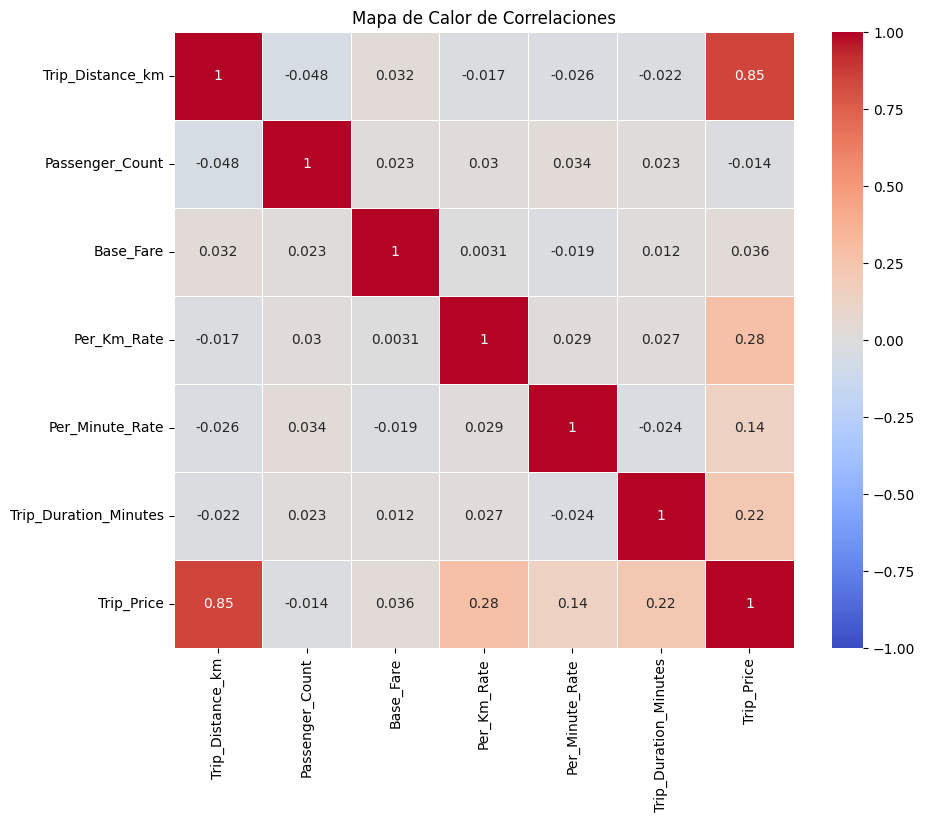

In [ ]:
## Matriz de correlacion en las variables numericas
variables_numericas = dataset_taxis.select_dtypes(include='number')
print(variables_numericas.columns)
variables_numericas.corr()

## Mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(variables_numericas.corr(), annot=True, cmap='coolwarm', linewidths=0.5, vmax=1.0, vmin=-1.0)
plt.title('Mapa de Calor de Correlaciones')

In [ ]:
## Revisar multicolinealidad

## Función para calcular VIF ()
from sklearn.linear_model import LinearRegression
def calculate_vif(df, features):    
    vif, tolerance = {}, {}
    # all the features that you want to examine
    for feature in features:
        # extract all the other features you will regress against
        X = [f for f in features if f != feature]        
        X, y = df[X], df[feature]
        # extract r-squared from the fit
        r2 = LinearRegression().fit(X, y).score(X, y)                

        # calculate tolerance
        tolerance[feature] = 1 - r2
        # calculate VIF
        vif[feature] = 1/(tolerance[feature])
    # return VIF DataFrame
    return pd.DataFrame({'VIF': vif, 'Tolerance': tolerance})


In [ ]:
variables_numericas =  variables_numericas.dropna()

## Resultados:
## 1 – las características no están correlacionadas
## 1<VIF<5 – las características están moderadamente correlacionadas
## VIF>5 – las características están altamente correlacionadas
## VIF>10: alta correlación entre las características y es motivo de preocupación
calculate_vif(df=variables_numericas, features=variables_numericas.columns.tolist())

,VIF,Tolerance
Trip_Distance_km,7.625344,0.131142
Passenger_Count,1.016083,0.984172
Base_Fare,1.005881,0.994154
Per_Km_Rate,1.576943,0.634138
Per_Minute_Rate,1.255646,0.796403
Trip_Duration_Minutes,1.460359,0.684763
Trip_Price,8.825705,0.113305


In [38]:
variables_numericas.columns.tolist()

['Trip_Distance_km',
 'Passenger_Count',
 'Base_Fare',
 'Per_Km_Rate',
 'Per_Minute_Rate',
 'Trip_Duration_Minutes',
 'Trip_Price']

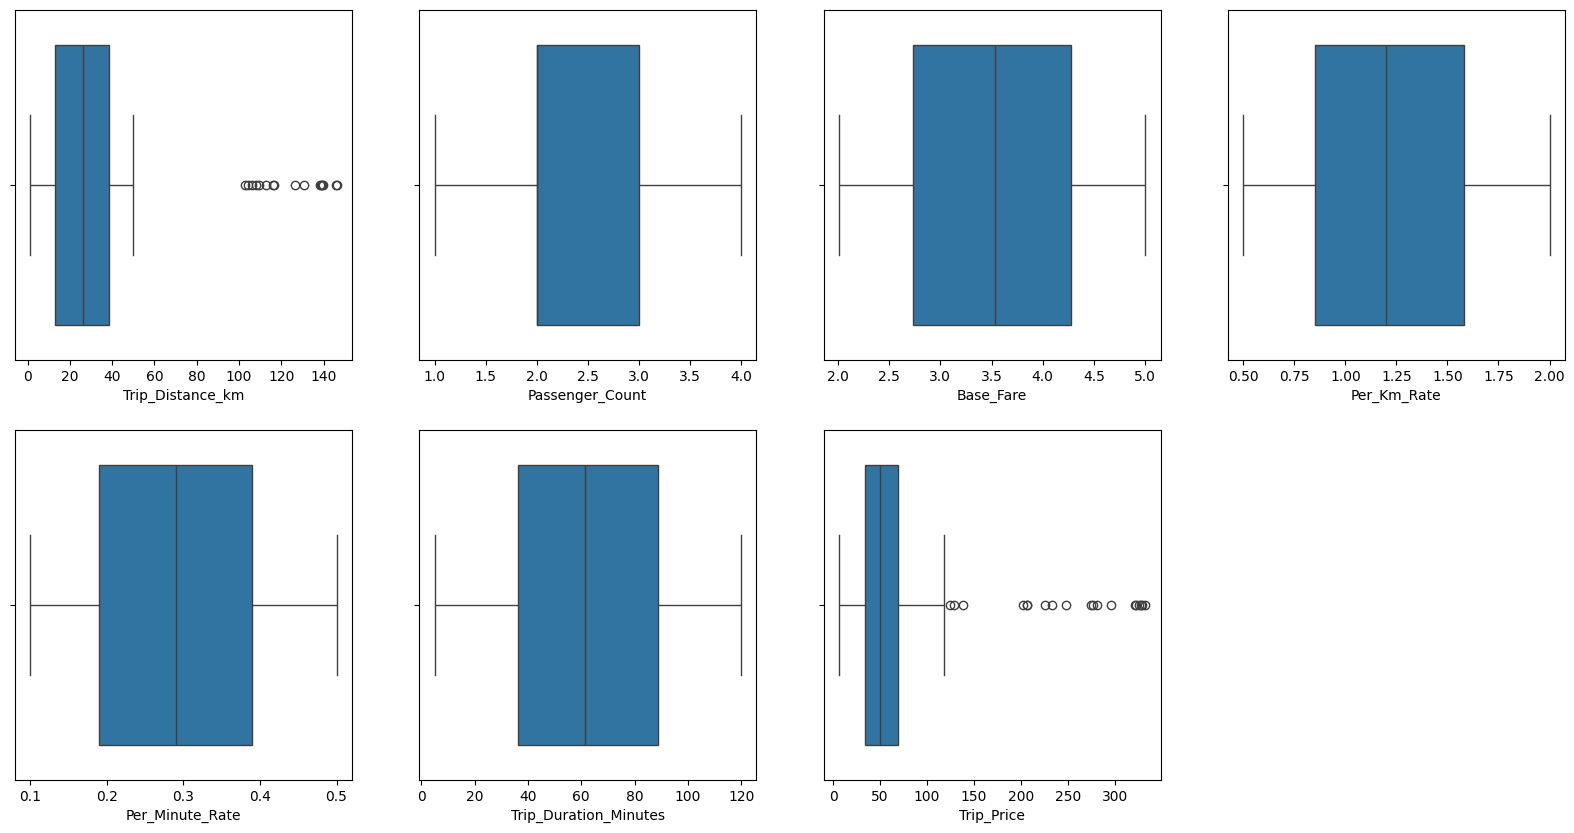

In [49]:
## Revisar Outliers o datos atípicos
plt.figure(figsize=(20, 10))
for i in range(len(variables_numericas.columns)):
    plt.subplot(2, 4, i+1)
    sns.boxplot(x=variables_numericas[variables_numericas.columns[i]])
    

<Axes: xlabel='Trip_Distance_km', ylabel='Trip_Price'>

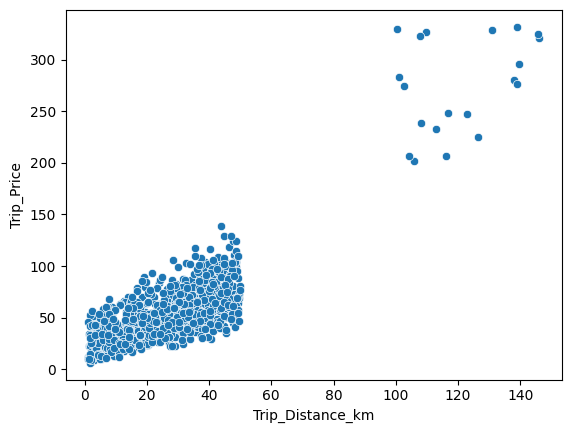

In [51]:
## RElacion entre precio y distancia
sns.scatterplot(x=dataset_taxis['Trip_Distance_km'], y=dataset_taxis['Trip_Price'])

## 3. Preprocesamiento de datos

1. Eliminar los registros con "Trip_Price" nulo o vacio
2. Separar el conjunto de datos en entrenamiento y prueba
3. Para todas las demás variables debo encontrar una manera de imputar o rellenar los valores faltantes 
    - 3.1 Uso de Covarianza
    - 3.2 Uso de la media o mediana / el valor más frecuente para las columnas categoricas
    - 3.3 Usar un valor "Desconocido" por defecto para las variables categoricas, aislando aquellas observaciones de las demás

In [ ]:
## Eliminar nulos en la variable objetivo
dataset_taxis = dataset_taxis.dropna(subset=['Trip_Price'])
dataset_taxis.shape

(951, 11)

In [56]:
## Separar los datos en entrenamiento y prueba

X = dataset_taxis.drop("Trip_Price", axis=1)
y = dataset_taxis["Trip_Price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [74]:
## Imputacion y escalado de las variables númericas y transformacion de las variables categoricas
One_hot = ['Day_of_Week']
TargetMean = ["Time_of_Day", "Traffic_Conditions"]
Frecuency = ["Weather"]
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

transformador_columnas = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imp", IterativeImputer()),
            ("scaler", StandardScaler())
        ]), num_cols),

        ("onehot", Pipeline([
            ("imp", SimpleImputer(strategy="constant", fill_value="Unknown")),
            ("oh", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), One_hot),

        ("target_mean", Pipeline([
            ("imp", SimpleImputer(strategy="constant", fill_value="Unknown")),
            ("te", ce.TargetEncoder())
        ]), TargetMean),

        ("freq", Pipeline([
            ("imp", SimpleImputer(strategy="constant", fill_value="Unknown")),
            ("fe", ce.CountEncoder(normalize=True))
        ]), Frecuency),
    ],
    remainder="passthrough"
)

## 4. Modelamiento

In [75]:
# Escogemos un modelo de Regresion, por ejemplo un arbol de decision, y lo integramos en un pipeline junto con el preprocesamiento.
from sklearn.tree import DecisionTreeRegressor

decision_tree_pipeline = Pipeline(steps=[
    ("preprocesar_columnas", transformador_columnas),
    ("modelo_ML", DecisionTreeRegressor(random_state=42))
])

In [77]:
## Entrenamiento
decision_tree_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocesar_columnas', ...), ('modelo_ML', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('onehot', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of th

In [78]:
## Prediccion 
y_pred = decision_tree_pipeline.predict(X_test)

In [82]:
y_test

210    31.3844
445    97.4848
730    19.1069
790    47.1770
533    55.7598
        ...   
37     40.9225
35     54.1018
748    50.8979
320    42.0962
648    61.8710
Name: Trip_Price, Length: 191, dtype: float64

In [83]:
y_pred

array([ 49.7657    , 110.2544    ,  22.7573    ,  51.4584    ,
        87.6076    ,  34.5781    ,  28.7235    ,  36.9301    ,
        28.7235    ,  35.3572    ,  39.2366    ,  22.0141    ,
        76.5803    ,  51.6275    ,  75.927     , 100.2662    ,
        66.2817    ,  48.0134    ,  30.0888    ,   8.7296    ,
        41.6562    ,  51.0588    ,  47.375     ,  55.1892    ,
        23.6949    ,  30.9982    ,  19.2572    ,  45.8161    ,
        54.6715    ,  62.1295    ,  78.9521    ,  56.3456    ,
        94.5643    ,  73.5544    ,  23.6949    ,  48.027     ,
        47.8469    ,  73.5544    ,  42.9921    ,  46.6313    ,
        78.6478    ,  29.0553    ,  84.2323    ,  82.0828    ,
        36.118     , 108.2325    ,  50.7312    ,  56.0596    ,
        47.8469    ,  23.6949    ,  36.4212    ,  72.1607    ,
       206.50865197,  70.8329    , 201.86950919,  26.9202    ,
        71.3962    ,  48.0066    ,  45.6194    ,  61.5494    ,
        46.1779    ,  19.5819    ,  35.3812    ,  79.71

## 5. Evaluación del modelo

REGRESIÓN Arbol de decisión:
MSE: 410.125
RMSE: 20.252
R²: 0.825



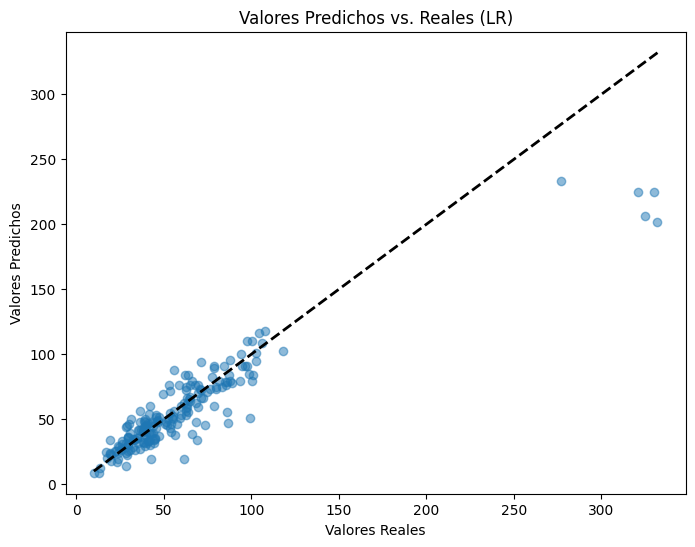

In [86]:
# Métricas
from numpy import sqrt


print("REGRESIÓN Arbol de decisión:")
print(f"MSE: {mean_squared_error(y_test, y_pred):.3f}")
print(f"RMSE: {sqrt(mean_squared_error(y_test, y_pred)):.3f}")
print(f"R²: {r2_score(y_test, y_pred):.3f}\n")
# Visualización
# Crear un gráfico de dispersión de valores predichos vs. reales
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.title('Valores Predichos vs. Reales (LR)')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)  # Línea de referencia
plt.show()

## 